In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [21]:
data = pd.read_csv("datasets/abalone.csv")

In [22]:
data.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [23]:
data["Sex"].unique()

array(['M', 'F', 'I'], dtype=object)

In [24]:
data.loc[data['Sex']=='I','Sex'] = 0
data.loc[data['Sex']=='M','Sex'] = 1
data.loc[data['Sex']=='F','Sex'] = 2

In [25]:
data['Sex'] = data['Sex'].astype('int')

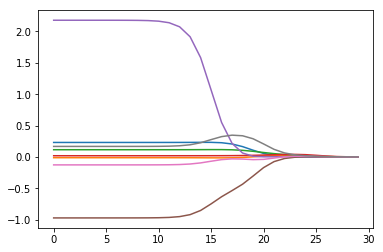

In [26]:
import numpy as np
import matplotlib.pyplot as plt
 
def ridgeRegres(xMat,yMat,lam=0.2):
    xTx = xMat.T*xMat
    denom = xTx + np.eye(np.shape(xMat)[1])*lam
    if np.linalg.det(denom) == 0.0:
        print("This matrix is singular, cannot do inverse")
        return
    ws = denom.I * (xMat.T*yMat)
    return ws
 
def ridgeTest(xArr,yArr):
    xMat = np.mat(xArr); yMat=np.mat(yArr).T
    yMean = np.mean(yMat) # 数据标准化
    # print(yMean)
    yMat = yMat - yMean
    # print(xMat)
    #regularize X's
    xMeans = np.mean(xMat,0)
    xVar = np.var(xMat,0)
    xMat = (xMat - xMeans) / xVar #（特征-均值）/方差
    numTestPts = 30
    wMat = np.zeros((numTestPts,np.shape(xMat)[1]))
    for i in range(numTestPts): # 测试不同的lambda取值，获得系数
        ws = ridgeRegres(xMat,yMat,np.exp(i-10))
        wMat[i,:]=ws.T
    return wMat
xArr = data.iloc[:,:-1]
yArr = data.iloc[:,-1]
# print(xArr,yArr)
ridgeWeights = ridgeTest(xArr,yArr)
# print(ridgeWeights)
plt.plot(ridgeWeights)
plt.show()